In [1]:
import os
import sys

# Path to the dataset zip file
data_folder = "./data"

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
sys.path.append(project_root)

from examples.minv.mimic.utils.preprocess_mimic_data_aud import preprocess_data, extract_features_and_split

input_path = os.path.join(data_folder, "df.pkl")
lab_events_path = os.path.join(data_folder, "lab_events_grouped.pkl")

# List of all possible continuous columns in MIMIC
# Note: Not all of these columns are guaranteed to be present in the dataset after feature selection
continuous_col_names = ['length_of_stay', 'num_procedures', 'num_medications', 'BMI',
       'BMI (kg/m2)', 'Height', 'Height (Inches)', 'Weight', 'Weight (Lbs)',
       'eGFR', 'systolic', 'diastolic']

# Creates processed_data.pkl
processed_path = preprocess_data(input_path, lab_events_path, continuous_col_names, mean_imputation=True)

# Feature selection
desired_num_unique_classes = 20
desired_num_features = 50
# Creates private private_df.pkl and public_df.pkl
extract_features_and_split(processed_path, desired_num_unique_classes, desired_num_features,print_classification_reports=False)

Rows before filtering: 593087
Rows after filtering:  592131
Imputing missing values with mean...
Merging lab events with main dataset...


KeyboardInterrupt: 

identity
3830    7401
1787    6753
5224    5797
3833    5475
1245    4593
        ... 
9808       1
9807       1
9806       1
9804       1
7111       1
Name: count, Length: 14218, dtype: int64


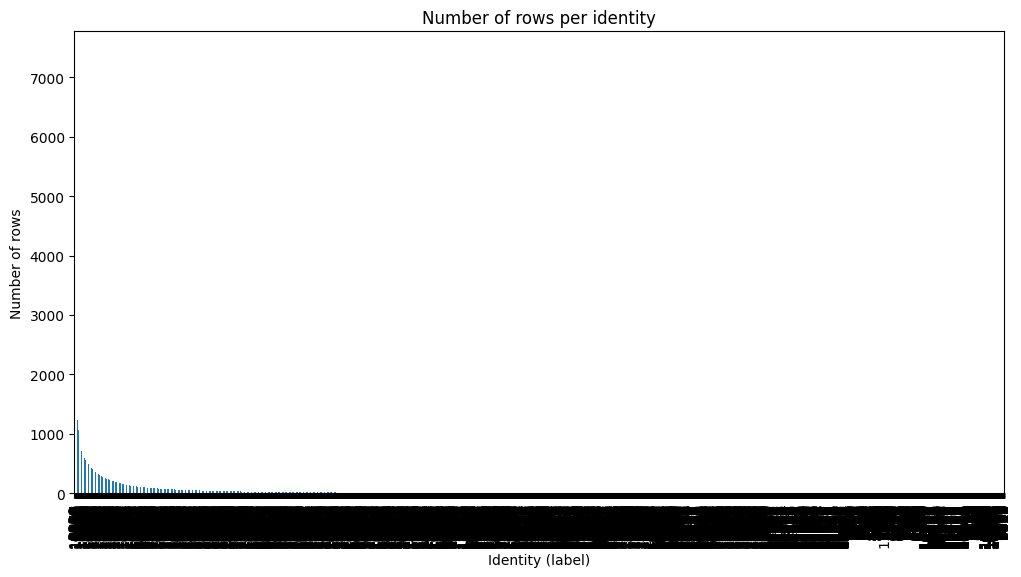

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load your dataframe from pickle
df = pd.read_pickle("data/processed_data.pkl")

# Count rows per label
counts = df['identity'].value_counts()

# Print the counts
print(counts)

# Plot histogram / bar chart
counts.plot(kind='bar', figsize=(12,6))
plt.xlabel("Identity (label)")
plt.ylabel("Number of rows")
plt.title("Number of rows per identity")
plt.show()

In [ ]:
# Total number of unique classes
num_classes = df["identity"].nunique()
print("Total number of classes:", num_classes)

# Count how many rows per class
counts = df["identity"].value_counts()

# How many classes have more than X rows (say X=1000)
X = 1000
num_classes_over_X = (counts > X).sum()
print(f"Number of classes with more than {X} rows:", num_classes_over_X)

# Optional: list those classes and their counts
print(counts[counts > X])

Total number of classes: 14218
Number of classes with more than 1000 rows: 70
identity
3830    7401
1787    6753
5224    5797
3833    5475
1245    4593
        ... 
1170    1038
6778    1031
3755    1029
3837    1017
5777    1008
Name: count, Length: 70, dtype: int64


In [ ]:
import matplotlib.pyplot as plt

# Count rows per class
counts = df["identity"].value_counts()

# Set threshold (change as you like)
X = 1000  

# Filter classes with more than X rows
counts_over_X = counts[counts > X]

print(f"Number of classes with more than {X} rows:", len(counts_over_X))

# Plot histogram (bar chart)
counts_over_X.plot(kind="bar", figsize=(12,6))
plt.xlabel("Identity (class label)")
plt.ylabel("Number of rows")
plt.title(f"Classes with more than {X} rows")
plt.show()


ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
# Total number of rows
total_rows = len(df)

# Number of rows in classes with more than X samples
rows_in_big_classes = counts_over_X.sum()

# Ratio
ratio = rows_in_big_classes / total_rows

print(f"Total rows: {total_rows}")
print(f"Rows in classes with >{X} samples: {rows_in_big_classes}")
print(f"Ratio: {ratio:.2%}")


Total rows: 592131
Rows in classes with >1000 samples: 158596
Ratio: 26.78%


In [ ]:
import pandas as pd

# Adjust the path to where you saved it
public_df = pd.read_pickle("data/private_df.pkl")

print(public_df.head())          # Look at first rows
print(public_df['identity'].unique())  # Check all unique identity values
print(public_df['identity'].isna().sum())  # Count how many NaNs
print(public_df['identity'].nunique(dropna=False))  # Include NaN in unique count

        Weight (Lbs)  BMI (kg/m2)  Height (Inches)  num_medications  \
330021    138.690244    20.673913        67.703750              180   
316450    148.833333    27.400000        62.000000              152   
372589    224.500000    28.923344        65.820733               52   
143088    152.506977    25.873810        64.376471              154   
330279    106.153333    17.935714        64.277778              100   

        num_procedures  length_of_stay race insurance gender  \
330021               6              16    7         4      1   
316450               6               8   18         1      0   
372589               0               2   28         4      1   
143088               3              19    3         0      1   
330279               2              10   28         4      0   

        curr_service_MED  ...  50910  50960  curr_service_OBS  med_Furosemide  \
330021              True  ...   True   True             False           False   
316450             False  

In [ ]:
import os
import sys
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import treegrad as tgd
import joblib
# Path to the dataset zip file
data_folder = "./data"

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
sys.path.append(project_root)

df_private = pd.read_pickle(os.path.join(data_folder, "private_df.pkl"))

print(df_private.columns)
print(df_private.shape)

Index(['Weight (Lbs)', 'BMI (kg/m2)', 'Height (Inches)', 'num_medications',
       'num_procedures', 'length_of_stay', 'race', 'insurance', 'gender',
       'curr_service_MED', 'curr_service_CMED', '51248', '51249', '50912',
       '51003', '50931', '51006', '51301', '50970', '51265', '51275', '51277',
       'med_Aspirin', '51250', '50882', '50902', '51221',
       'med_Sodium Chloride 0.9%  Flush', '50893', '51279',
       'curr_service_OMED', '52172', '51222', 'curr_service_SURG', '51256',
       'med_Acetaminophen', '50971', '51274', '51237', '50983', '51244',
       'med_Heparin', '50910', '50960', 'curr_service_OBS', 'med_Furosemide',
       'curr_service_NMED', '50868', '51493', '50878', 'identity'],
      dtype='object')
(23792, 51)


# TreeGrad

In [ ]:

# --------- 1) Get your data ---------
# Assumes you already have a pandas DataFrame named df_private in memory.
# If your data is on disk, replace the next line with: df_private = pd.read_csv("your_file.csv")
assert isinstance(df_private, pd.DataFrame), "df_private must be a pandas DataFrame."

# Heuristic target detection
candidate_targets = [c for c in ["target", "label", "y"] if c in df_private.columns]
target_col = candidate_targets[0] if candidate_targets else df_private.columns[-1]

X = df_private.drop(columns=[target_col])
y = df_private[target_col]

# --------- 2) Train/validation split ---------
# Stratify if it looks like classification (discrete labels)
stratify = y if (y.nunique() < 50 and pd.api.types.is_integer_dtype(y) or pd.api.types.is_object_dtype(y)) else None
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify
)

# --------- 3) Preprocessing: OHE for categoricals, pass-through numerics ---------
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# --------- 4) TreeGrad model (sklearn-style) ---------
tgd_model = tgd.TGDClassifier(
    num_leaves=31,
    max_depth=-1,
    learning_rate=0.1,
    n_estimators=100,
    autograd_config={"refit_splits": False}
)

clf = Pipeline(steps=[
    ("prep", preprocess),
    ("tgd", tgd_model)
])

# --------- 5) Train ---------
clf.fit(X_train, y_train)

# Optionally, do an online update on more data:
# clf.named_steps["tgd"].partial_fit(preprocess.transform(X_train), y_train)

# --------- 6) Evaluate ---------
y_pred = clf.predict(X_val)
try:
    acc = accuracy_score(y_val, y_pred)
    print(f"Validation accuracy: {acc:.4f}")
except Exception:
    pass
print(classification_report(y_val, y_pred))

# --------- 7) Save the trained pipeline (preprocessing + model) ---------
model_path = "treegrad_model.pkl"
joblib.dump(clf, model_path)
print(f"Saved model to: {model_path}")

# --------- 8) How to load & use later ---------
# clf = joblib.load("treegrad_model.pkl")
# preds = clf.predict(new_df)  # new_df is a pandas DataFrame with the same columns as X

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005019 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1360
[LightGBM] [Info] Number of data points in the train set: 19033, number of used features: 124
[LightGBM] [Info] Start training from score -4.948655
[LightGBM] [Info] Start training from score -3.778584
[LightGBM] [Info] Start training from score -4.884116
[LightGBM] [Info] Start training from score -4.791335
[LightGBM] [Info] Start training from score -4.956090
[LightGBM] [Info] Start training from score -4.978732
[LightGBM] [Info] Start training from score -4.724031
[LightGBM] [Info] Start training from score -3.524209
[LightGBM] [Info] Start training from score -3.818448
[LightGBM] [Info] Start training from score -3.797146
[LightGBM] [Info] Start training from score -3.197203
[LightGBM] [Info] Start training from score -4.82349

Exception ignored on calling ctypes callback function: <function _log_callback at 0x7f681e31d940>
Traceback (most recent call last):
  File "/home/fazeleh/miniconda3/envs/treegrad-env/lib/python3.9/site-packages/lightgbm/basic.py", line 287, in _log_callback
    def _log_callback(msg: bytes) -> None:
KeyboardInterrupt: 


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

/home/fazeleh/miniconda3/envs/treegrad-env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/fazeleh/miniconda3/envs/treegrad-env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/fazeleh/miniconda3/envs/treegrad-env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/fazeleh/miniconda3/envs/treegrad-env/lib/python3.9/site-packages/sklearn/metr

Validation accuracy: 0.0540
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        24
           2       0.00      0.00      0.00       116
           3       0.00      0.00      0.00        27
           4       0.00      0.00      0.00        34
           5       0.00      0.00      0.00        29
           6       0.00      0.00      0.00        25
           7       0.00      0.00      0.00        46
           8       0.02      0.09      0.04       128
           9       0.00      0.00      0.00       108
          10       0.00      0.00      0.00       114
          11       0.00      0.00      0.00       235
          12       0.00      0.00      0.00        53
          13       0.00      0.00      0.00        52
          14       0.00      0.00      0.00        94
          15       0.00      0.00      0.00        33
          16       0.00      0.00      0.00        69
          17       0.07      0.05      0.06        63

# TabularModel

In [ ]:
X_train.shape

In [ ]:
# -------- SPLIT TRAIN / VAL / TEST (TreeGrad-style) --------
import random, numpy as np, os
from sklearn.metrics import accuracy_score, classification_report

# Reproducibility
seed = 123
random.seed(seed); np.random.seed(seed)
try:
    import torch
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
except Exception:
    pass

# df_private -> df (as in your snippet)
df = df_private.copy().reset_index(drop=True)

# Fractions (use your config if available; else defaults)
# Total must satisfy: f_train + f_val + f_test = 1
try:
    import yaml
    with open("train_config.yaml", "r") as f:
        _cfg = yaml.safe_load(f)
    f_train = float(_cfg["data"].get("f_train", 0.8))
    f_val   = float(_cfg["data"].get("f_val",   0.1))
except Exception:
    f_train, f_val = 0.8, 0.1
f_test = max(0.0, 1.0 - f_train - f_val)
assert 0 < f_train < 1 and 0 <= f_val < 1 and 0 <= f_test < 1 and abs(f_train+f_val+f_test-1.0) < 1e-6

target_col = "identity"
classes = df[target_col].unique()

# Ensure train has at least one sample per class
df_train_min = df.groupby(target_col).head(1)
remaining_df = df.drop(df_train_min.index)

# Bring train up to desired fraction
desired_frac = f_train
frac_already = len(df_train_min) / len(df)
frac_remaining_needed = max(0.0, desired_frac - frac_already)
df_train_remaining = remaining_df.sample(frac=frac_remaining_needed, random_state=seed) if frac_remaining_needed > 0 else remaining_df.iloc[0:0]

train_indices = df_train_min.index.union(df_train_remaining.index)
df_train = df.loc[train_indices]

# Pool for val+test from same classes as train
eval_pool = df.drop(train_indices)
eval_pool = eval_pool[eval_pool[target_col].isin(df_train[target_col].unique())].reset_index(drop=True)

# Split eval_pool into val and test with the requested proportions of the REMAINDER
# Convert global fractions to local (within eval_pool)
rem = 1.0 - f_train
frac_val_of_rem = 0.0 if rem == 0 else (f_val / rem)
n_val = int(round(frac_val_of_rem * len(eval_pool)))
df_val = eval_pool.sample(n=n_val, random_state=seed)
df_test = eval_pool.drop(df_val.index).reset_index(drop=True)
df_val  = df_val.reset_index(drop=True)

print(f"Classes in train: {df_train[target_col].nunique()} / {len(classes)}")
print(f"Shapes -> train: {df_train.shape}, val: {df_val.shape}, test: {df_test.shape}")

# -------- Pytorch-Tabular configs (reuse your lists) --------
# Keep only continuous names that exist
continuous_col_names = [c for c in continuous_col_names if c in df.columns]
categorical_col_names = [c for c in df.columns if c not in continuous_col_names]
if target_col in categorical_col_names:
    categorical_col_names.remove(target_col)

data_config = DataConfig(
    target=[target_col],
    continuous_cols=continuous_col_names,
    categorical_cols=categorical_col_names,
    normalize_continuous_features=False,
)

trainer_config = TrainerConfig(
    auto_lr_find=False,
    batch_size=1024,              # try 512/1024 depending on memory
    max_epochs=50,                # was 150
    early_stopping="val_loss",    # stop on validation metric (much better)
    accelerator="auto",           # GPU if available
    devices="auto",               # pick GPU device automatically
    precision=16,                 # mixed precision
    deterministic=False,          # allow faster kernels
    enable_progress_bar=False,    # less overhead
)
optimizer_config = OptimizerConfig()

# Pick your model config (you had GANDALF)
model_config = GANDALFConfig(
    task="classification",
    gflu_stages=8,        # was 32
    gflu_dropout=0.01,
    embedding_dropout=0.1,
    learning_rate=1e-3,
)

tabular_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config,
)

# -------- Train with FIXED validation (our df_val) --------
tabular_model.fit(train=df_train, validation=df_val)

# -------- Evaluate on VAL --------
X_val = df_val.drop(columns=[target_col])
y_val = df_val[target_col].values
val_pred_df = tabular_model.predict(X_val)
val_pred = val_pred_df["prediction"].values
val_acc = accuracy_score(y_val, val_pred)
print(f"\nValidation accuracy: {val_acc:.4f}")
print("Validation report:\n", classification_report(y_val, val_pred))

# -------- Evaluate on TEST --------
X_test = df_test.drop(columns=[target_col])
y_test = df_test[target_col].values
test_pred_df = tabular_model.predict(X_test)
test_pred = test_pred_df["prediction"].values
test_acc = accuracy_score(y_test, test_pred)
print(f"\nTest accuracy: {test_acc:.4f}")
print("Test report:\n", classification_report(y_test, test_pred))

# (Optional) library’s evaluate on test
results = tabular_model.evaluate(df_test)
print("\nPyTorch-Tabular evaluate(df_test):")
print(results)

# -------- Save model --------
os.makedirs("./target/", exist_ok=True)
tabular_model.save_model("./target/")
print('Saved model to "./target/".')


Classes in train: 20 / 20
Shapes -> train: (4145, 52), val: (8292, 52), test: (70485, 52)


NameError: name 'continuous_col_names' is not defined